<h1 style="font-family: 'Times New Roman'; text-align: center;"><b>Karachi Real Estate Anomaly Detection</b></h1>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>1. Import Libraries</b></h3>

In [44]:
import pandas as pd
import numpy as np
import re
import warnings
import os
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import pandera as pa
from matplotlib.patches import Rectangle
from pandera import Column, DataFrameSchema, Check
sns.set_style("whitegrid")
sns.set_context("notebook")

# Plotting style
plt.rcParams.update({
    'figure.facecolor': '#fafaf8',
    'axes.facecolor':   '#fafaf8',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
})
ACCENT = '#c84b1e'
BLUE   = '#1a5fa8'
GREEN  = '#1a6b3f'

np.random.seed(42)

<h3 style="font-family: 'Times New Roman'; color: red;"><b>2. Data Gathering</b></h3>

In [45]:
real_estate=pd.read_csv('data/raw/raw_listings.csv')

In [46]:
# Keep only Karachi For Sale listings
real_estate = real_estate[ (real_estate['city'].str.lower() == 'karachi') & (real_estate['purpose'] == 'For Sale')].copy()
n_before = len(real_estate)

<h3 style="font-family: 'Times New Roman'; color: red;"><b>3. Data Assessment</b></h3>

-----------------------------------
<p style="font-family: 'Arial';color: black; font-size:16px;"><i><b>Goal: Look at the raw data carefully before changing anything. Understand the shape, column types, missing values, and any obvious problems.</i></b></p>

---

In [47]:
#Check shpae
real_estate.shape

(46669, 17)

In [48]:
#Check columns
real_estate.columns.tolist()

['property_id',
 'location_id',
 'page_url',
 'property_type',
 'price',
 'location',
 'city',
 'province_name',
 'latitude',
 'longitude',
 'baths',
 'area',
 'purpose',
 'bedrooms',
 'date_added',
 'agency',
 'agent']

In [49]:
#First Look
real_estate.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
156,86575,6649,https://www.zameen.com/Property/faisal_cantonm...,House,450000000,Cantt,Karachi,Sindh,24.889395,67.098627,7,4 Kanal,For Sale,6,6/20/2019,Premier Properties,Aamir Motiwala
157,342005,232,https://www.zameen.com/Property/karachi_gulist...,House,35000000,Gulistan-e-Jauhar,Karachi,Sindh,24.914988,67.138702,8,16 Marla,For Sale,6,7/18/2019,NaN,NaN
158,466607,1484,https://www.zameen.com/Property/d_h_a_dha_phas...,Flat,21000000,DHA Defence,Karachi,Sindh,24.814367,67.072083,3,8.9 Marla,For Sale,3,10/20/2018,NaN,NaN
159,678919,9594,https://www.zameen.com/Property/malir_malir_ka...,House,6500000,Malir,Karachi,Sindh,24.882302,67.184677,1,3.2 Marla,For Sale,2,3/10/2019,NaN,NaN
160,813506,6732,https://www.zameen.com/Property/surjani_town_s...,House,13000000,Gadap Town,Karachi,Sindh,25.018156,67.066864,4,9.6 Marla,For Sale,4,7/18/2019,NaN,NaN


In [50]:
#Random sample
real_estate.sample(6)

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
49111,15321969,10016,https://www.zameen.com/Property/bahria_town_ka...,Flat,7500000,Bahria Town Karachi,Karachi,Sindh,25.047400,67.313864,3,5.1 Marla,For Sale,2,3/19/2019,Time Properties,Hassan
38365,14611769,6902,https://www.zameen.com/Property/gulshan_e_iqba...,Flat,12000000,Gulshan-e-Iqbal Town,Karachi,Sindh,24.889589,67.061180,3,6 Marla,For Sale,3,6/5/2019,NaN,NaN
40438,14750288,1484,https://www.zameen.com/Property/d_h_a_dha_phas...,House,34000000,DHA Defence,Karachi,Sindh,24.821639,67.071691,4,4 Marla,For Sale,3,3/18/2019,Estate Era,Estate Era
79058,16503341,6884,https://www.zameen.com/Property/gulzar_e_hijri...,Upper Portion,7500000,Gulshan-e-Iqbal Town,Karachi,Sindh,24.951550,67.109420,3,5.1 Marla,For Sale,3,6/14/2019,Deebaj Real Estate,Umar naseer
107004,16963469,10019,https://www.zameen.com/Property/bahria_town_ka...,House,11000000,Bahria Town Karachi,Karachi,Sindh,25.065275,67.313384,3,8 Marla,For Sale,3,7/2/2019,Land Professional Associate,Rao Riffat Iqbal
147637,17245677,8978,https://www.zameen.com/Property/surjani_town_s...,Flat,1425000,Gadap Town,Karachi,Sindh,25.045686,67.072513,1,2 Marla,For Sale,1,7/12/2019,Al Dinas Enterprises,Anas Qureshi


In [51]:
#Check missing values
real_estate.isnull().sum()



,0
property_id,0
location_id,0
page_url,0
property_type,0
price,0
location,0
city,0
province_name,0
latitude,0
longitude,0


In [52]:
#Check Datatypes and nulls
real_estate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46669 entries, 156 to 168445
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_id    46669 non-null  int64  
 1   location_id    46669 non-null  int64  
 2   page_url       46669 non-null  object 
 3   property_type  46669 non-null  object 
 4   price          46669 non-null  int64  
 5   location       46669 non-null  object 
 6   city           46669 non-null  object 
 7   province_name  46669 non-null  object 
 8   latitude       46669 non-null  float64
 9   longitude      46669 non-null  float64
 10  baths          46669 non-null  int64  
 11  area           46669 non-null  object 
 12  purpose        46669 non-null  object 
 13  bedrooms       46669 non-null  int64  
 14  date_added     46669 non-null  object 
 15  agency         34464 non-null  object 
 16  agent          34464 non-null  object 
dtypes: float64(2), int64(5), object(10)
memory usage: 7.

In [53]:
# Check statistics
real_estate.describe(include='all')

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
count,4.666900e+04,46669.000000,46669,46669,4.666900e+04,46669,46669,46669,46669.000000,46669.000000,46669.000000,46669,46669,46669.000000,46669,34464,34464
unique,NaN,NaN,46669,7,NaN,197,1,1,NaN,NaN,NaN,250,1,NaN,90,1924,3636
top,NaN,NaN,https://www.zameen.com/Property/bahria_town_ka...,House,NaN,Bahria Town Karachi,Karachi,Sindh,NaN,NaN,NaN,8 Marla,For Sale,NaN,5/6/2019,Real Investment Consultants,Boez Ayub
freq,NaN,NaN,1,21600,NaN,7682,46669,46669,NaN,NaN,NaN,4888,46669,NaN,3759,398,391
mean,1.559267e+07,6147.124151,NaN,NaN,2.568075e+07,NaN,NaN,NaN,24.927586,67.121404,2.617155,NaN,NaN,3.070389,NaN,NaN,NaN
std,2.189027e+06,3737.430638,NaN,NaN,4.185798e+07,NaN,NaN,NaN,0.251584,0.129831,1.961131,NaN,NaN,1.809827,NaN,NaN,NaN
min,8.657500e+04,2.000000,NaN,NaN,0.000000e+00,NaN,NaN,NaN,24.749425,57.839654,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN
25%,1.491246e+07,1484.000000,NaN,NaN,6.500000e+06,NaN,NaN,NaN,24.876665,67.059045,2.000000,NaN,NaN,2.000000,NaN,NaN,NaN
50%,1.661953e+07,6862.000000,NaN,NaN,1.250000e+07,NaN,NaN,NaN,24.924038,67.077749,3.000000,NaN,NaN,3.000000,NaN,NaN,NaN
75%,1.706393e+07,9030.000000,NaN,NaN,2.500000e+07,NaN,NaN,NaN,24.972287,67.140593,3.000000,NaN,NaN,4.000000,NaN,NaN,NaN


In [54]:
#check duplicate data
real_estate.duplicated().sum()

np.int64(0)

In [55]:
#check missing values percentage
print("Percentage of zeros:")
print((real_estate['baths'] == 0).mean() * 100)
print((real_estate['bedrooms'] == 0).mean() * 100)
print((real_estate['price'] == 0).mean() * 100)

Percentage of zeros:
21.768197304420493
9.758083524395209
0.002142750005356875


<h3 style="font-family: 'Times New Roman'; color: red;"><b>4. Schema Validation</b></h3>
<hr>
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Goal: Automatically check that every column has the correct data type and value range. This catches problems that are hard to see manually.</b></i>
</p>
<hr>

In [56]:
ingestion_schema = DataFrameSchema({
    "price": Column(int, Check.greater_than_or_equal_to(0), nullable=False),
    "bedrooms": Column(int, Check.in_range(0, 50), nullable=False),
    "baths": Column(int, Check.in_range(0, 50), nullable=False),

    # Tightened to match geographic anomaly detection bounds
    "latitude": Column(
        float,
        Check.in_range(24.74, 25.19),
        nullable=False
    ),
    "longitude": Column(
        float,
        Check.in_range(66.68, 67.53),
        nullable=False
    ),

    "property_type": Column(str, nullable=False),
    "location": Column(str, nullable=False),
    "area": Column(str, nullable=False),
    "date_added": Column(str, nullable=False),
}, coerce=True)

In [57]:
try:
    ingestion_schema.validate(real_estate, lazy=True)
    print("Schema validation PASSED (data types + ranges are correct)")
except pa.errors.SchemaErrors as e:
    print(f"Schema violations found: {len(e.failure_cases)} cases")
    print(e.failure_cases.head(20))

Schema violations found: 22 cases
   schema_context     column                   check  check_number  \
0          Column   latitude  in_range(24.74, 25.19)             0   
1          Column   latitude  in_range(24.74, 25.19)             0   
20         Column  longitude  in_range(66.68, 67.53)             0   
19         Column  longitude  in_range(66.68, 67.53)             0   
18         Column  longitude  in_range(66.68, 67.53)             0   
17         Column  longitude  in_range(66.68, 67.53)             0   
16         Column  longitude  in_range(66.68, 67.53)             0   
15         Column  longitude  in_range(66.68, 67.53)             0   
14         Column  longitude  in_range(66.68, 67.53)             0   
13         Column  longitude  in_range(66.68, 67.53)             0   
12         Column  longitude  in_range(66.68, 67.53)             0   
11         Column  longitude  in_range(66.68, 67.53)             0   
10         Column  longitude  in_range(66.68, 67.53)    

<h3 style="font-family: 'Times New Roman'; color: red;"><b>5. Initial Eda</b></h3>
<hr>  
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Goal: Look at basic distributions to understand what the data looks like before cleaning. No new columns are created here.</b></i>
</p>
<hr>

Area unit breakdown:
0
Marla    42710
Kanal     3959
Name: count, dtype: int64


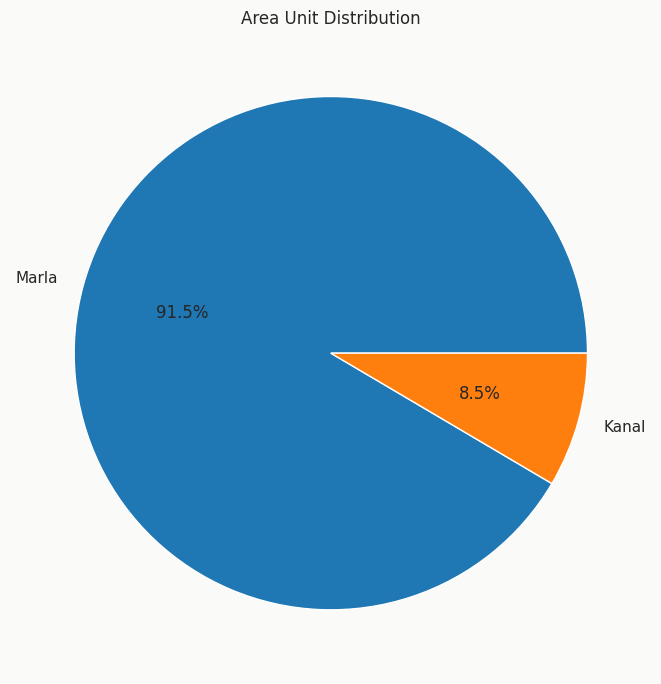

In [58]:
# Check what units exist in area column

unit_counts = real_estate['area'].str.extract(r'(Marla|Kanal|Sq\. Yd\.|Sq\. Ft\.)')[0].value_counts()
print('Area unit breakdown:')
print(unit_counts)

# Plot pie chart
plt.figure(figsize=(10, 7))
unit_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Area Unit Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('reports/figures/initial_eda_area_unit_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

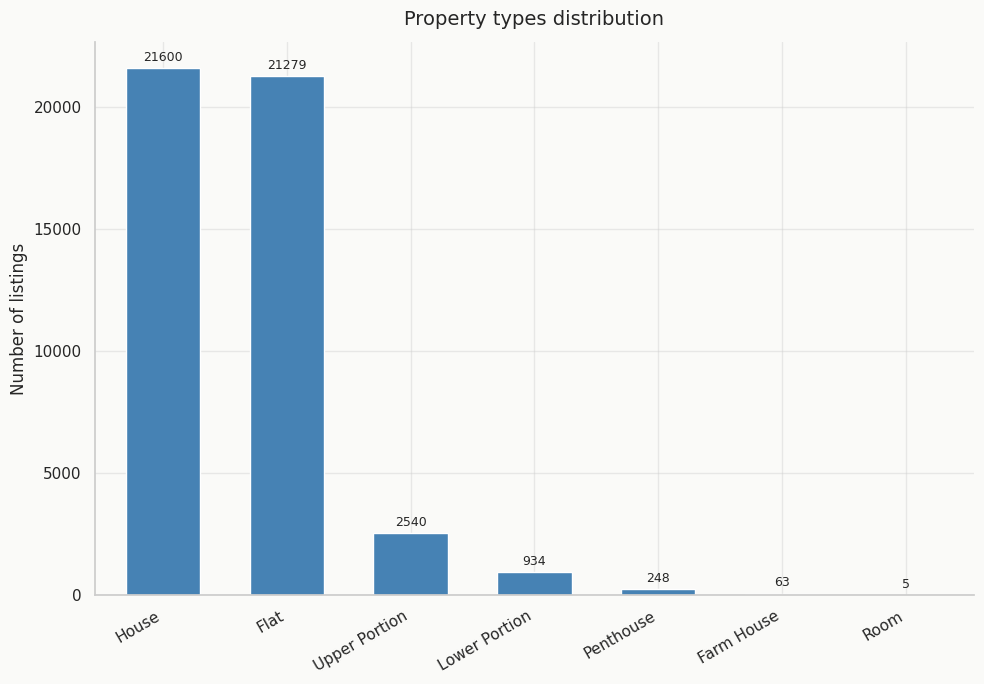

In [59]:
#property_types
data = real_estate['property_type'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 7))

# Plot
data.plot(kind='bar', color='steelblue', width=0.6)

plt.title('Property types distribution', fontsize=14, pad=12)
plt.xlabel('')
plt.ylabel('Number of listings')

plt.xticks(rotation=30, ha='right')

# Add value labels on bars
ax = plt.gca()
ax.bar_label(ax.containers[0], padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("reports/figures/initial_eda_property_types.png", dpi=150, bbox_inches='tight')
plt.show()

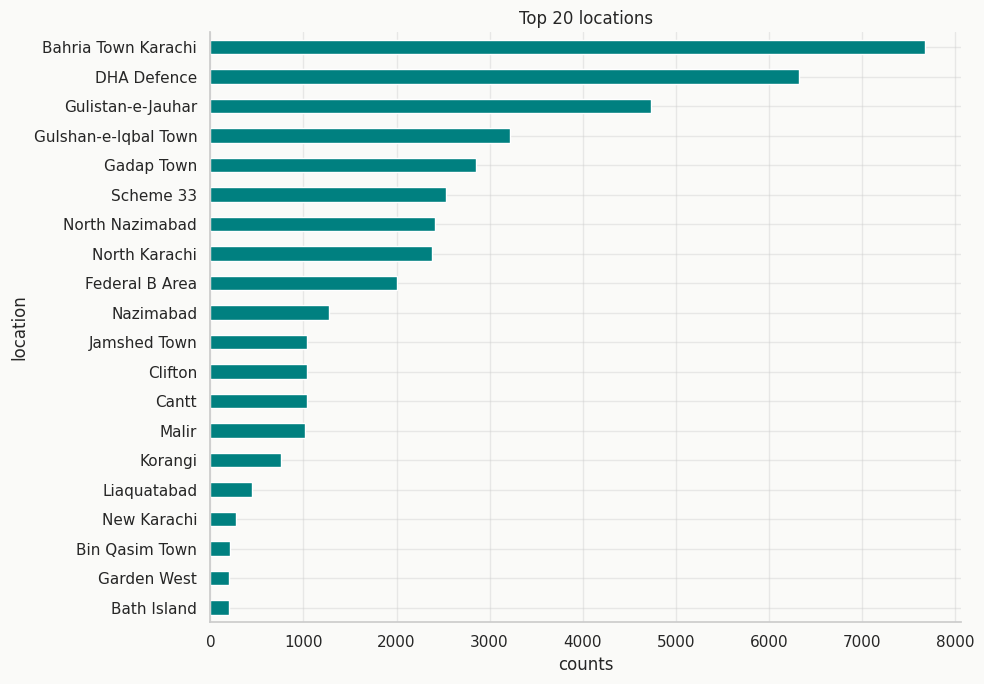

In [60]:
# Top areas by listing count
plt.figure(figsize=(10, 7))
real_estate['location'].value_counts().head(20).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Top 20 locations')
plt.xlabel("counts")
plt.tight_layout()
plt.savefig("reports/figures/initial_eda_top20_locations.png", dpi=150, bbox_inches='tight')
plt.show()

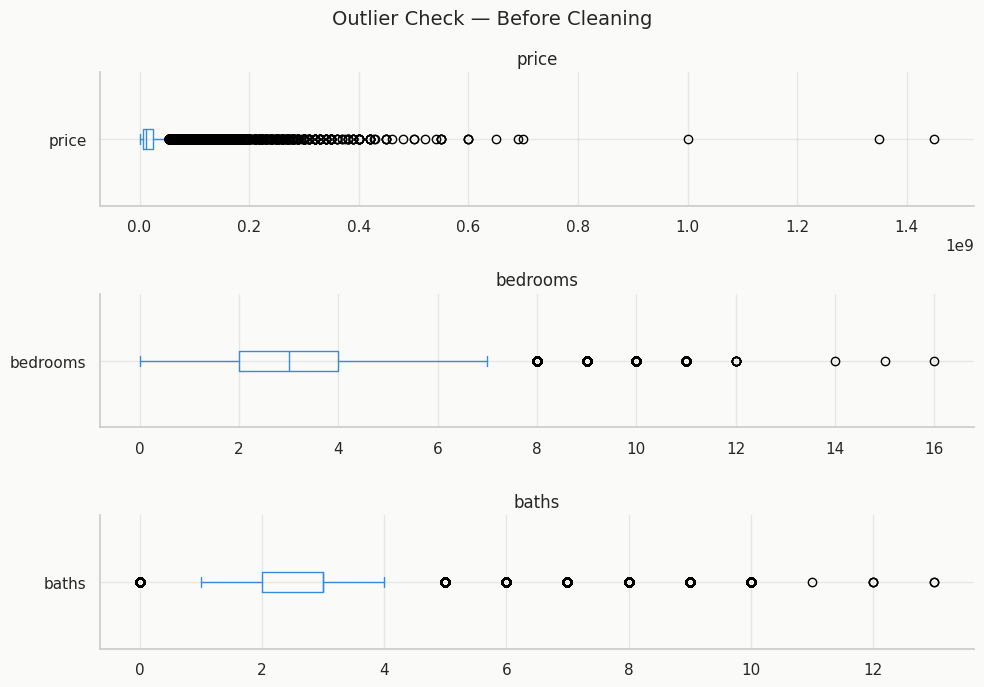

In [61]:
# Box plots for price, bedrooms, baths
fig, axes = plt.subplots(3, 1, figsize=(10, 7))
fig.suptitle('Outlier Check — Before Cleaning', fontsize=14)
for ax, col in zip(axes, ['price', 'bedrooms', 'baths']):
    real_estate[col].plot(kind='box', ax=ax, vert=False, color='#378ADD')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('reports/figures/initial_eda_box_plot_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Dataset size:</b> After filtering for Karachi For Sale listings, we have 46,669 rows and 17 columns. No duplicate rows were found, so no deduplication is needed.</li>
<li><b>Area units:</b> Almost all listings use Marla (91.5%) or Kanal (8.5%). Both will be converted to sqft so all area values can be compared on the same scale.</li>
<li><b>Property types:</b> House (21,600) and Flat (21,279) are the two largest categories, together about 92% of all listings. The remaining 8% is spread across Upper Portion, Lower Portion, Penthouse, Room, and Farm House.</li>
<li><b>Top locations:</b> Bahria Town Karachi (7,682 listings) and DHA Defence together account for about 30% of the data. Results from location-level analysis will be strongly influenced by these two areas.</li>
<li><b>Price outliers:</b> The box plot shows extreme prices reaching PKR 1.45 billion. These are almost certainly data entry errors because no residential listing in Karachi in 2019 was genuinely worth that amount.</li>
<li><b>Bedrooms and baths:</b> Both columns have zeros, meaning the seller left the field blank. These are not real zero-bedroom properties due to which they are missing values that need to be filled.</li>
</i></ul>
<hr>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>6. Data Cleaning</b></h3>

---
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Data Cleaning Goal: Drop useless columns, convert area to sqft, remove impossible values, fix data types, and fill missing bedroom and bathroom values using location-based medians.</b></i>
</p>

----

In [62]:
# Drop columns not needed for analysis
cols_to_drop = ['location_id','city', 'province_name', 'agency', 'agent', 'purpose']
real_estate=real_estate.drop(columns=cols_to_drop)
print("Remaining columns:", real_estate.columns.tolist())
print("Shape:", real_estate.shape)

Remaining columns: ['property_id', 'page_url', 'property_type', 'price', 'location', 'latitude', 'longitude', 'baths', 'area', 'bedrooms', 'date_added']
Shape: (46669, 11)


In [63]:
# Normalize area to sqft

def convert_to_sqft(val: str) -> float:
    """
    Convert any Pakistani area string to square feet.
    Returns np.nan for unknown units.
    """
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()
    num_match = re.search(r'[\d.]+', val_str)
    if not num_match:
        return np.nan
    num = float(num_match.group())
    val_lower = val_str.lower()

    if 'kanal' in val_lower:
        return num * 5445.0
    elif 'marla' in val_lower:
        return num * 272.25
    elif 'sq. yd.' in val_lower or 'sq yd' in val_lower:
        return num * 9.0
    elif 'sq. ft.' in val_lower or 'sq ft' in val_lower:
        return num
    return np.nan   # unknown unit


real_estate['area_sqft'] = real_estate['area'].apply(convert_to_sqft)

print(f"Null area_sqft after conversion : {real_estate['area_sqft'].isnull().sum()}")
print(f"area_sqft range                 : {real_estate['area_sqft'].min():.0f} – {real_estate['area_sqft'].max():,.0f} sqft")
print("\narea_sqft percentiles:")
print(real_estate['area_sqft'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

Null area_sqft after conversion : 0
area_sqft range                 : 0 – 3,267,000 sqft

area_sqft percentiles:
count    4.666900e+04
mean     2.414722e+03
std      1.556071e+04
min      0.000000e+00
1%       4.900500e+02
5%       7.078500e+02
25%      1.143450e+03
50%      1.633500e+03
75%      2.613600e+03
95%      5.445000e+03
99%      1.089000e+04
max      3.267000e+06
Name: area_sqft, dtype: float64


In [64]:
# Remove impossible rows which are definite data errors, not anomalies

mask_price_zero = real_estate['price'] == 0
mask_area_zero = (real_estate['area_sqft'] <= 0) | (real_estate['area_sqft'].isna())
mask_baths_extreme =real_estate['baths'] > 30

removal_log = {
    'price_zero'       : mask_price_zero.sum(),
    'area_zero_or_null': mask_area_zero.sum(),
    'baths_over_30'    : mask_baths_extreme.sum(),
}
combined_mask = mask_price_zero | mask_area_zero | mask_baths_extreme
real_estate = real_estate[~combined_mask].copy()

print('Impossible Value Removal:')
for reason, count in removal_log.items():
    print(f'  {reason:<25}: {count} rows removed')
print(f'\nTotal removed : {n_before - len(real_estate)}')
print(f'Rows remaining: {len(real_estate):,}')

Impossible Value Removal:
  price_zero               : 1 rows removed
  area_zero_or_null        : 1 rows removed
  baths_over_30            : 0 rows removed

Total removed : 2
Rows remaining: 46,667


In [65]:
# Fix date_added column
real_estate['date_added'] = pd.to_datetime(real_estate['date_added'], errors='coerce')
null_dates = real_estate['date_added'].isnull().sum()
print(f"Date range       : {real_estate['date_added'].min().date()} → {real_estate['date_added'].max().date()}")
print(f"Unparseable dates: {null_dates}")

Date range       : 2018-08-07 → 2019-07-18
Unparseable dates: 0


In [66]:
# Fixing bedrooms = 0 using group-wise median
real_estate['bedrooms'] = real_estate['bedrooms'].replace(0, np.nan)
#falback
real_estate['bedrooms'] = real_estate.groupby(['location', 'property_type'])['bedrooms'].transform(lambda x: x.fillna(x.median()))
#Remaining handle null values
real_estate['bedrooms'] = real_estate['bedrooms'].fillna(real_estate['bedrooms'].median())
real_estate['bedrooms'] = real_estate['bedrooms'].round().astype(int)
print("Bedrooms after fix:")
print(real_estate['bedrooms'].value_counts().sort_index())


Bedrooms after fix:
bedrooms
1       602
2     13735
3     16964
4      6011
5      3187
6      4516
7       634
8       489
9       218
10      152
11      148
12        8
14        1
15        1
16        1
Name: count, dtype: int64


In [67]:
# Fix baths = 0 using group-wise median
real_estate['baths'] = real_estate['baths'].replace(0, np.nan)

real_estate['baths'] = real_estate.groupby(['location', 'property_type', 'bedrooms'])['baths'].transform(lambda x: x.fillna(x.median()))
real_estate['baths'] = real_estate.groupby(['location', 'property_type'])['baths'].transform(lambda x: x.fillna(x.median()))
real_estate['baths'] = real_estate['baths'].fillna(real_estate['baths'].median())

real_estate['baths'] = real_estate['baths'].round().astype(int)
print("Baths after fix:")
print(real_estate['baths'].value_counts().sort_index())

Baths after fix:
baths
1      1261
2     13738
3     16552
4      6095
5      2907
6      4182
7       958
8       597
9       193
10      178
11        1
12        3
13        2
Name: count, dtype: int64


<h3 style="font-family: 'Times New Roman'; color: red;"><b>7. Ghost Listing Detection</b></h3>

---
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Goal: Identify and flag properties relisted 5+ times within 30 days as ghost listings, a fraud pattern where sellers repost repeatedly to dominate search results.</b></i>
</p>

----

In [68]:
#Define duplicate key columns
# Same price + location + type + bedrooms + baths + area = same physical property
DUPE_KEY = ['price', 'location', 'property_type', 'bedrooms', 'baths', 'area']

#  Count how many times each unique property was listed
relisting_stats = real_estate.groupby(DUPE_KEY).agg(
    relisting_count   = ('property_id',  'count'),
    unique_url_count  = ('page_url',     'nunique'),
    first_listed      = ('date_added',   'min'),
    last_listed       = ('date_added',   'max'),
).reset_index()

In [69]:
relisting_stats['relisting_span_days'] = (relisting_stats['last_listed'] - relisting_stats['first_listed']).dt.days

real_estate = real_estate.merge( relisting_stats[DUPE_KEY + ['relisting_count','unique_url_count','relisting_span_days']],
                                on=DUPE_KEY,
                                how='left'
                                )

In [70]:
# Ghost listing flag: listed 5 or more times
ghost_relist_threshold = 5
ghost_span_days = 30

real_estate['ghost_listing_flag'] = (
    (real_estate['relisting_count'] >= ghost_relist_threshold) &
    (real_estate['relisting_span_days'] <= ghost_span_days)
).astype(int)

ghost_count = real_estate['ghost_listing_flag'].sum()
ghost_pct = real_estate['ghost_listing_flag'].mean() * 100

print(f"\nGhost listings detected: {ghost_count:,} "
      f"({ghost_pct:.2f}% of all listings)")
print(f"Criteria: relisted ≥ {ghost_relist_threshold} times "
      f"within {ghost_span_days} days")


Ghost listings detected: 4,258 (9.12% of all listings)
Criteria: relisted ≥ 5 times within 30 days


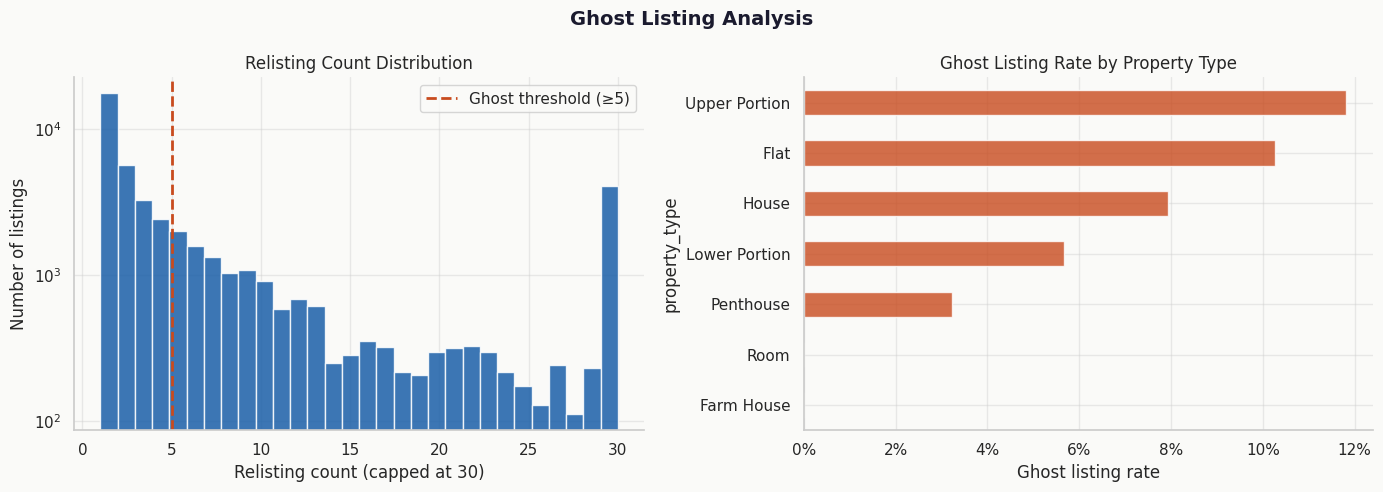

In [71]:
#Visualise: relisting count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ghost Listing Analysis', fontsize=14, fontweight='bold', color='#1a1a2e')

# Distribution of relisting counts
axes[0].hist(real_estate['relisting_count'].clip(upper=30), bins=30, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(ghost_relist_threshold, color=ACCENT, linestyle='--', linewidth=2,
                label=f'Ghost threshold (≥{ghost_relist_threshold})')
axes[0].set_xlabel('Relisting count (capped at 30)')
axes[0].set_ylabel('Number of listings')
axes[0].set_title('Relisting Count Distribution')
axes[0].legend()
axes[0].set_yscale('log')

# Ghost rate by property type
ghost_by_type = real_estate.groupby('property_type')['ghost_listing_flag'].mean().sort_values(ascending=True)
ghost_by_type.plot(kind='barh', ax=axes[1], color=ACCENT, alpha=0.8)
axes[1].set_xlabel('Ghost listing rate')
axes[1].set_title('Ghost Listing Rate by Property Type')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.savefig(f'reports/figures/ghost_listings_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [72]:
# ── Weekly volume features (computed on full dataset — no future leakage) ────
# listing_date and location are observable at the time a listing is posted,
# so computing volume counts on the full dataset does not leak future labels.

real_estate['year_week'] = real_estate['date_added'].dt.to_period('W').astype(str)

weekly_counts = (
    real_estate
    .groupby(['location', 'year_week'])
    .size()
    .reset_index(name='listings_per_week_in_area')
)

real_estate = real_estate.merge(weekly_counts, on=['location', 'year_week'], how='left')

print(f'listings_per_week_in_area range: '
      f'{real_estate["listings_per_week_in_area"].min()} – '
      f'{real_estate["listings_per_week_in_area"].max()}')
print(f'Spike weeks (>50 listings): '
      f'{(real_estate["listings_per_week_in_area"] > 50).sum():,}')

listings_per_week_in_area range: 1 – 1874
Spike weeks (>50 listings): 37,217


<h3 style="font-family: 'Times New Roman'; color: red;"><b>8. Geographic Anomaly Detection</b></h3>

---
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Goal: Flag listings with coordinates that fall outside Karachi's geographic boundaries.
A property "in Karachi" with coordinates in Lahore or outside Pakistan is either a data error or deliberate fraud.</b></i>
</p>

----

In [73]:

# Karachi bounding box (WGS84)
# Source: OpenStreetMap Nominatim API

# Karachi geographic boundary constants
KARACHI_LAT_MIN = 24.74
KARACHI_LAT_MAX = 25.19
KARACHI_LON_MIN = 66.68
KARACHI_LON_MAX = 67.53

# Create anomaly flags
real_estate['lat_anomaly'] = ((real_estate['latitude']  < KARACHI_LAT_MIN) |(real_estate['latitude']  > KARACHI_LAT_MAX)).astype(int)

real_estate['lon_anomaly'] = ( (real_estate['longitude'] < KARACHI_LON_MIN) | (real_estate['longitude'] > KARACHI_LON_MAX)).astype(int)

real_estate['geo_anomaly'] = ((real_estate['lat_anomaly'] == 1) | (real_estate['lon_anomaly'] == 1)).astype(int)

print("Geographic Anomaly Results:")
print(f"Latitude  out of bounds : {real_estate['lat_anomaly'].sum():>3} rows")
print(f"Longitude out of bounds : {real_estate['lon_anomaly'].sum():>3} rows")
print(f"Any geo anomaly (union) : {real_estate['geo_anomaly'].sum():>3} rows  (union of both)")
print()
print("Anomalous rows detail:")
geo_rows = real_estate[real_estate['geo_anomaly'] == 1][
    ['location', 'latitude', 'longitude', 'price', 'area', 'property_type']
]
print(geo_rows.to_string(index=False))

Geographic Anomaly Results:
Latitude  out of bounds :   9 rows
Longitude out of bounds :  13 rows
Any geo anomaly (union) :  13 rows  (union of both)

Anomalous rows detail:
         location  latitude  longitude   price      area property_type
    North Karachi 72.610337  57.839654 8000000 3.2 Marla         House
            Malir 33.749464  73.061142 8500000 4.8 Marla         House
  University Road 31.422218  73.088951 3200000   4 Marla          Flat
Gulistan-e-Jauhar 31.422218  73.088951 7500000 4.8 Marla         House
       Gadap Town 33.749464  73.061142 5500000   5 Marla         House
   Manzoor Colony 31.422218  73.088951 3600000 2.9 Marla          Flat
M. A. Jinnah Road 31.422218  73.088951 4000000 4.2 Marla          Flat
      Saddar Town 31.422218  73.088951 3500000 2.7 Marla          Flat
       Gadap Town 31.422218  73.088951 6000000 4.3 Marla          Flat
        Nooriabad 25.158484  67.798475 6200000 5.3 Marla          Flat
 Karachi Motorway 25.077935  67.541729 550000

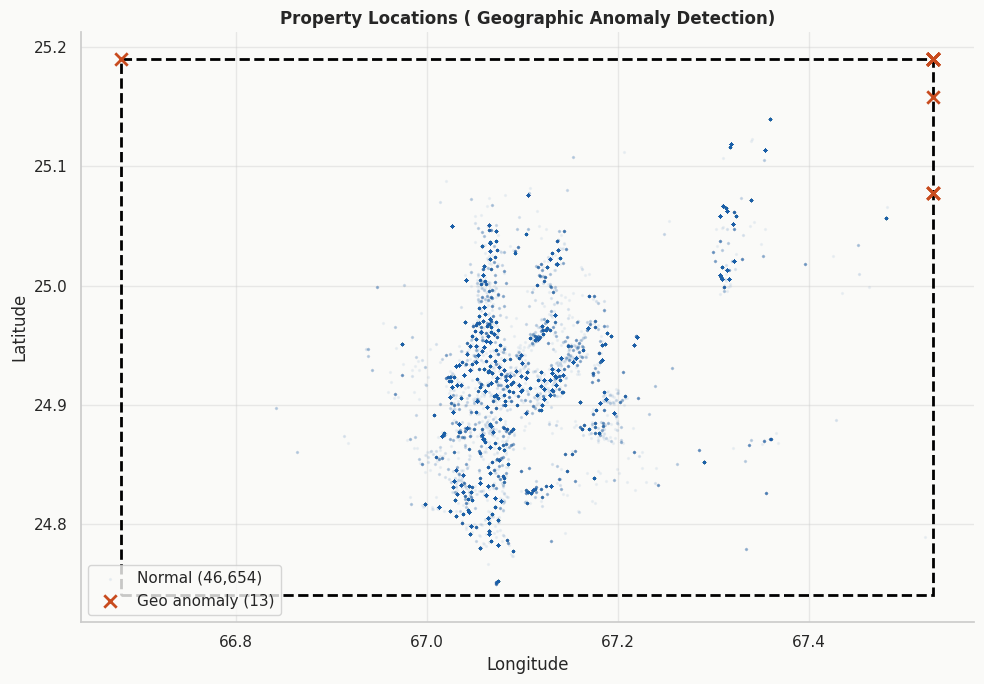

In [74]:
#Visualise geographic distribution
fig, ax = plt.subplots(figsize=(10, 7))
normal =real_estate[real_estate['geo_anomaly'] == 0]
anomal = real_estate[real_estate['geo_anomaly'] == 1]

ax.scatter(normal['longitude'].clip(KARACHI_LON_MIN, KARACHI_LON_MAX),
           normal['latitude'].clip(KARACHI_LAT_MIN, KARACHI_LAT_MAX),
           alpha=0.05, s=2, color=BLUE, label=f'Normal ({len(normal):,})')

ax.scatter(anomal['longitude'].clip(KARACHI_LON_MIN, KARACHI_LON_MAX),
           anomal['latitude'].clip(KARACHI_LAT_MIN, KARACHI_LAT_MAX),
           color=ACCENT, s=80, zorder=5, marker='x', linewidths=2,
           label=f'Geo anomaly ({len(anomal):,})')

# Karachi boundary box
box = Rectangle((KARACHI_LON_MIN, KARACHI_LAT_MIN),
                KARACHI_LON_MAX - KARACHI_LON_MIN,
                KARACHI_LAT_MAX - KARACHI_LAT_MIN,
                linewidth=2, edgecolor='black', facecolor='none', linestyle='--')

ax.add_patch(box)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Property Locations ( Geographic Anomaly Detection)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'reports/figures/geo_anomaly_map.png', dpi=150, bbox_inches='tight')
plt.show()

<h3 style="font-family: 'Times New Roman'; color: red;"><b>9. Price Anomaly Flags</b></h3>

---
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Goal: Flag prices that are implausible given Karachi's 2019 market.
These flags are KEPT in the data because they are anomaly signals, not errors.</b></i>
</p>

----

In [75]:
# Karachi property price anomaly thresholds (PKR) — 2019 data
# Source: Zameen.com Karachi Property Market Report 2019
# Cheapest realistic listings in 2019 were approximately 4-5M PKR

PRICE_TOO_LOW  = 1_000_000     # Less than PKR 1M (too cheap for any real listing)
PRICE_TOO_HIGH = 500_000_000   # More than PKR 500M (ultra-luxury or data error)

real_estate['price_too_low_flag']   = (real_estate['price'] < PRICE_TOO_LOW).astype(int)
real_estate['price_very_high_flag'] = (real_estate['price'] > PRICE_TOO_HIGH).astype(int)

print("Price anomaly flags:")
print(f"  price_too_low_flag   = 1 : {real_estate['price_too_low_flag'].sum():>4} rows")
print(f"  price_very_high_flag = 1 : {real_estate['price_very_high_flag'].sum():>4} rows")

Price anomaly flags:
  price_too_low_flag   = 1 :  177 rows
  price_very_high_flag = 1 :   15 rows


In [76]:
# Summary of all anomaly flags added in this notebook
flag_cols = ['ghost_listing_flag', 'geo_anomaly', 'price_too_low_flag', 'price_very_high_flag']

real_estate['suspicious_flag_count'] = real_estate[flag_cols].sum(axis=1)
real_estate['is_suspicious'] = (real_estate['suspicious_flag_count'] >= 1).astype(int)

print("=" * 55)
print("CLEANING SUMMARY")
print("=" * 55)
print(f"  Original rows     : {n_before:,}")
print(f"  Rows removed      : {n_before - len(real_estate):,}  (confirmed data errors only)")
print(f"  Rows retained     : {len(real_estate):,}")
print(f"  Columns in output : {real_estate.shape[1]}")
print()
print("Anomaly Flags Added (rows KEPT, just flagged):")
for col in flag_cols:
    n   = real_estate[col].sum()
    pct = n / len(real_estate) * 100
    print(f'  {col:<30}: {n:,} ({pct:.1f}%)')
print()
n_sus = real_estate['is_suspicious'].sum()
print(f'  Total suspicious (any flag)   : {n_sus:,} ({n_sus/len(real_estate)*100:.1f}%)')
print(f'  Total clean (no flags)        : {len(real_estate)-n_sus:,} ({(len(real_estate)-n_sus)/len(real_estate)*100:.1f}%)')

CLEANING SUMMARY
  Original rows     : 46,669
  Rows removed      : 2  (confirmed data errors only)
  Rows retained     : 46,667
  Columns in output : 25

Anomaly Flags Added (rows KEPT, just flagged):
  ghost_listing_flag            : 4,258 (9.1%)
  geo_anomaly                   : 13 (0.0%)
  price_too_low_flag            : 177 (0.4%)
  price_very_high_flag          : 15 (0.0%)

  Total suspicious (any flag)   : 4,463 (9.6%)
  Total clean (no flags)        : 42,204 (90.4%)


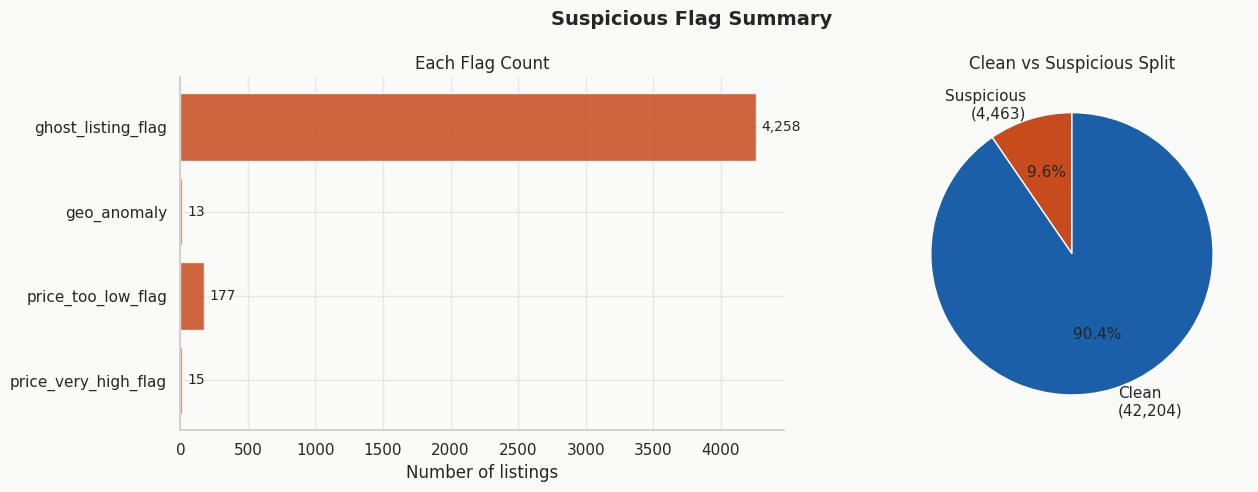

In [77]:
# Visualize overall flag summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Suspicious Flag Summary', fontsize=14, fontweight='bold')

flag_counts = real_estate[flag_cols].sum()
bars = axes[0].barh(list(flag_counts.index), list(flag_counts.values), color=ACCENT, alpha=0.85)
axes[0].bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=10)
axes[0].set_xlabel('Number of listings')
axes[0].set_title('Each Flag Count')
axes[0].invert_yaxis()

sizes  = [real_estate['is_suspicious'].sum(), (real_estate['is_suspicious'] == 0).sum()]
labels = [f'Suspicious\n({sizes[0]:,})', f'Clean\n({sizes[1]:,})']
axes[1].pie(sizes, labels=labels, colors=[ACCENT, BLUE], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Clean vs Suspicious Split')

plt.tight_layout()
plt.savefig('reports/figures/cleaning_flag_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
# Check for unexpected nulls in critical columns
critical_cols = ['price', 'area_sqft', 'bedrooms', 'baths', 'location']
for col in critical_cols:
    nulls = real_estate[col].isnull().sum()
    status = 'correct' if nulls == 0 else 'error'
    print(f"  {status} {col}: {nulls} nulls")

  correct price: 0 nulls
  correct area_sqft: 0 nulls
  correct bedrooms: 0 nulls
  correct baths: 0 nulls
  correct location: 0 nulls


In [79]:
# Save cleaned data
real_estate.to_csv('data/preprocessed/all_listings_with_flags.csv', index=False)
print(f"Saved cleaned_listings.csv ")
print(f"Shape: {real_estate.shape}")
print(f"Columns: {real_estate.columns.to_list()}")

# Also save a separate file with only the suspicious listings
df_flagged = real_estate[real_estate['is_suspicious'] == 1].copy()
df_flagged.to_csv('data/preprocessed/suspicious_listings.csv', index=False)
print(f'Saved flagged_at_cleaning.csv — Shape: {df_flagged.shape}')

Saved cleaned_listings.csv 
Shape: (46667, 25)
Columns: ['property_id', 'page_url', 'property_type', 'price', 'location', 'latitude', 'longitude', 'baths', 'area', 'bedrooms', 'date_added', 'area_sqft', 'relisting_count', 'unique_url_count', 'relisting_span_days', 'ghost_listing_flag', 'year_week', 'listings_per_week_in_area', 'lat_anomaly', 'lon_anomaly', 'geo_anomaly', 'price_too_low_flag', 'price_very_high_flag', 'suspicious_flag_count', 'is_suspicious']
Saved flagged_at_cleaning.csv — Shape: (4463, 25)


<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li>After filtering for Karachi "For Sale" listings, the dataset contains <b>46,669 rows</b> across 17 columns with no duplicate rows.</li>
<li><b>Useless columns dropped:</b> Removed <code>location_id</code>, <code>city</code>, <code>province_name</code>, <code>agency</code>, <code>agent</code>, and <code>purpose</code>. City and province were constant after the Karachi filter. Agency and agent each had 12,205 missing values (about 26% of rows) and are not needed for fraud detection.</li>
<li><b>Area converted to sqft:</b> Standardized all area values to square feet using Pakistani conversions (1 Marla = 272.25 sqft, 1 Kanal = 5,445 sqft).</li>
<li><b>Basic data cleaning:</b> Removed only truly impossible rows:
    <ul>
        <li>Price == 0</li>
        <li>Area_sqft <= 0 or missing</li>
        <li>Baths > 30</li>
    </ul>
    Total rows removed in this step: <b>2</b> (&lt; 0.1% of data). These are clear data entry errors.</li>
<li><b>Missing values imputation:</b>
    <ul>
        <li>Bedrooms (9.76% zero): Filled using median per <b>location + property_type</b>.</li>
        <li>Baths (21.77% zero): Filled using median per <b>location + property_type + bedrooms</b>.</li>
    </ul>
</li>
<li><b>Ghost listings flagged:</b> Properties with the same price, location, type, bedrooms, baths, and area that were relisted ≥5 times within 30 days are marked as ghost listings.</li>
<li><b>Geographic anomalies flagged:</b> Listings with latitude/longitude outside Karachi's realistic bounds ([24.74, 25.19], [66.68, 67.53]) were flagged.</li>
<li><b>Price anomalies flagged:</b> Listings below PKR 1 million or above PKR 500 million were flagged as suspicious.</li>
</ul></i>

<p style="font-family: 'Arial'; color: green; font-size:16px;">
<i><b>Final Dataset:</b><br>
After cleaning and feature engineering, the dataset contains <b>46,667 rows</b> and <b>25 columns</b>, with complete bedroom and bathroom values, and all columns needed for EDA and modeling.
</p>